Лабораторна робота 4

Глибокий аналіз і візуалізація даних

Завдання 1.

Провести аналіз даних. Зробити візуалізацію результатів. Написати висновки.

1/ Завантажити датасет, що містить інформацію про відвідуваність музеїв в різні роки.

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Museum_Visitors(in).csv to Museum_Visitors(in).csv


Вивести перші 5 рядків датасету.

In [6]:
import pandas as pd

df = pd.read_csv("Museum_Visitors(in).csv")

df.head(5)

,Month,America Tropical Interpretive Center,Avila Adobe,Chinese American Museum,Gateway to Nature Center,Firehouse Museum,Hellman Quon,IAMLA,Pico House,Visitor Center/ El Tranquilo Gallery,Museum of Social Justice,Biscailuz Gallery/ PK Outdoor Exhibit
0,01/01/2014 12:00:00 AM,6602,24778,1581,NaN,4486,0.0,NaN,2204.0,2961.0,NaN,NaN
1,02/01/2014 12:00:00 AM,5029,18976,1785,NaN,4172,0.0,NaN,1330.0,2276.0,NaN,NaN
2,03/01/2014 12:00:00 AM,8129,25231,3229,NaN,7082,70.0,NaN,4320.0,3116.0,NaN,NaN
3,04/01/2014 12:00:00 AM,2824,26989,2129,NaN,6756,250.0,NaN,3277.0,2808.0,NaN,NaN
4,05/01/2014 12:00:00 AM,10694,36883,3676,NaN,10858,135.0,NaN,4122.0,3987.0,NaN,NaN


Провести попередній аналіз даних (визначити розмір датасету, тип даних, кількість пропусків).

In [7]:
print("Розмір датасету:", df.shape)
print("\n")

print("Інформація про датасет:")
df.info()
print("\n")

print("Кількість пропусків у кожній колонці:")
print(df.isna().sum())
print("\n")

print("Статистичний опис:")
df.describe()

Розмір датасету: (85, 12)


Інформація про датасет:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Month                                  85 non-null     object 
 1   America Tropical Interpretive Center   85 non-null     int64  
 2   Avila Adobe                            85 non-null     int64  
 3   Chinese American Museum                85 non-null     int64  
 4   Gateway to Nature Center               32 non-null     float64
 5   Firehouse Museum                       85 non-null     int64  
 6   Hellman Quon                           26 non-null     float64
 7   IAMLA                                  54 non-null     float64
 8   Pico House                             83 non-null     float64
 9   Visitor Center/ El Tranquilo Gallery   45 non-null     float64
 10  Museum of Social Justice

,America Tropical Interpretive Center,Avila Adobe,Chinese American Museum,Gateway to Nature Center,Firehouse Museum,Hellman Quon,IAMLA,Pico House,Visitor Center/ El Tranquilo Gallery,Museum of Social Justice,Biscailuz Gallery/ PK Outdoor Exhibit
count,85.000000,85.000000,85.000000,32.000000,85.000000,26.000000,54.000000,83.000000,45.000000,37.000000,39.000000
mean,5637.694118,19904.952941,2359.117647,1247.375000,5286.776471,353.461538,882.611111,1329.710843,2634.800000,2125.972973,1088.615385
std,3277.453044,9495.340548,1360.427221,1212.137535,6591.535926,447.043106,507.197681,1832.519767,2055.530871,1954.845497,664.825565
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3891.000000,17056.000000,1785.000000,0.000000,3858.000000,81.250000,685.000000,177.500000,1769.000000,0.000000,794.000000
50%,5705.000000,20815.000000,2371.000000,1138.000000,4613.000000,180.000000,1020.000000,605.000000,2751.000000,2557.000000,933.000000
75%,6955.000000,25234.000000,2808.000000,1882.500000,5406.000000,458.750000,1202.250000,1597.500000,3323.000000,2911.000000,1306.000000
max,13490.000000,41242.000000,7702.000000,4227.000000,61192.000000,2000.000000,1883.000000,9312.000000,13750.000000,10740.000000,3801.000000


Перевірити наявність дублікатів. Якщо є, видалити їх і вивести розмір таблиці (без дублікатів).

In [8]:
duplicates = df.duplicated()
print("Кількість дублікатів:", duplicates.sum())

df = df.drop_duplicates()
print("Розмір датасету після видалення дублікатів:", df.shape)

Кількість дублікатів: 0
Розмір датасету після видалення дублікатів: (85, 12)


Про які роки містить інформацію датасет.

In [10]:
df["Month"] = pd.to_datetime(df["Month"])

years = df["Month"].dt.year.unique()

years.sort()

print("Роки в датасеті:", years)

Роки в датасеті: [2014 2015 2016 2017 2018 2019 2020 2021]


Змінити назви столбців. Замінити великі букви на маленьки, пробіли на підкреслення (date, avila_adobe, firehouse_museum, chinese_american_museum, america_tropical_interpretive_center).

In [11]:
df = df.rename(columns={
    "Month": "date",
    "America Tropical Interpretive Center": "america_tropical_interpretive_center",
    "Avila Adobe": "avila_adobe",
    "Firehouse Museum": "firehouse_museum",
    "Chinese American Museum": "chinese_american_museum",
    "Gateway to Nature Center": "gateway_to_nature_center",
    "Hellman Quon": "hellman_quon",
    "IAMLA": "iamla",
    "Pico House": "pico_house",
    "Visitor Center/ El Tranquilo Gallery": "visitor_center_el_tranquilo_gallery",
    "Museum of Social Justice": "museum_of_social_justice",
    "Biscailuz Gallery/ PK Outdoor Exhibit": "biscailuz_gallery_pk_outdoor_exhibit"
})

df.columns

Index(['date', 'america_tropical_interpretive_center', 'avila_adobe',
       'chinese_american_museum', 'gateway_to_nature_center',
       'firehouse_museum', 'hellman_quon', 'iamla', 'Pico House ',
       'visitor_center_el_tranquilo_gallery', 'museum_of_social_justice',
       'biscailuz_gallery_pk_outdoor_exhibit'],
      dtype='object')

Обчислити середню кількість відвідувачів для кожного музею протягом всього періоду.

In [12]:
museum_cols = df.columns.drop("date")
average_visitors = df[museum_cols].mean()
average_visitors = average_visitors.sort_values(ascending=False)

print("Середня кількість відвідувачів за весь період:")
print(average_visitors)

Середня кількість відвідувачів за весь період:
avila_adobe                             19904.952941
america_tropical_interpretive_center     5637.694118
firehouse_museum                         5286.776471
visitor_center_el_tranquilo_gallery      2634.800000
chinese_american_museum                  2359.117647
museum_of_social_justice                 2125.972973
Pico House                               1329.710843
gateway_to_nature_center                 1247.375000
biscailuz_gallery_pk_outdoor_exhibit     1088.615385
iamla                                     882.611111
hellman_quon                              353.461538
dtype: float64


Знайти мінімальну та максимальну кількість відвідувачів для кожного музею за 2018 рік

In [13]:
df_2018 = df[df["date"].dt.year == 2018]

In [14]:
museum_cols = df_2018.columns.drop("date")
min_visitors = df_2018[museum_cols].min()
max_visitors = df_2018[museum_cols].max()

result_2018 = pd.DataFrame({
    "min": min_visitors,
    "max": max_visitors
})

print(result_2018)

                                          min      max
america_tropical_interpretive_center   3180.0   5837.0
avila_adobe                           14718.0  25173.0
chinese_american_museum                2078.0   4960.0
gateway_to_nature_center                  NaN      NaN
firehouse_museum                       3306.0   8013.0
hellman_quon                              NaN      NaN
iamla                                   965.0   1601.0
Pico House                              185.0   2140.0
visitor_center_el_tranquilo_gallery       NaN      NaN
museum_of_social_justice               2332.0   3686.0
biscailuz_gallery_pk_outdoor_exhibit    349.0   1790.0


Визначити місяці з найвищою і найнижчою загальною кількістю відвідувачів серед усіх музеїв для 2015 року. Вивести назви місяців (не цифри).

In [16]:
df_2015 = df[df["date"].dt.year == 2015]

museum_cols = df.columns.drop("date")
df_2015["total_visitors"] = df_2015[museum_cols].sum(axis=1)

min_month = df_2015.loc[df_2015["total_visitors"].idxmin(), "date"].month_name()

max_month = df_2015.loc[df_2015["total_visitors"].idxmax(), "date"].month_name()

print("Місяць з найнижчою відвідуваністю:", min_month)
print("Місяць з найвищою відвідуваністю:", max_month)

Місяць з найнижчою відвідуваністю: February
Місяць з найвищою відвідуваністю: May


/tmp/ipykernel_2391/2406803351.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2015["total_visitors"] = df_2015[museum_cols].sum(axis=1)


Порівняти кількість відвідувачів музею "Avila Adobe" у літні і зимові місяці 2018 року

In [17]:
df_2018 = df[df["date"].dt.year == 2018]
df_2018["month"] = df_2018["date"].dt.month
summer_months = [6, 7, 8]
winter_months = [12, 1, 2]

summer_avg = df_2018[df_2018["month"].isin(summer_months)]["avila_adobe"].mean()

winter_avg = df_2018[df_2018["month"].isin(winter_months)]["avila_adobe"].mean()

print(f"Середня відвідуваність Avila Adobe влітку 2018 року: {summer_avg:.0f}")
print(f"Середня відвідуваність Avila Adobe взимку 2018 року: {winter_avg:.0f}")

Середня відвідуваність Avila Adobe влітку 2018 року: 22041
Середня відвідуваність Avila Adobe взимку 2018 року: 16235


/tmp/ipykernel_2391/2277150707.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2018["month"] = df_2018["date"].dt.month


Знайти кореляцію між кількістю відвідувачів в кожному з музеїв  та датами у 2016 році

In [18]:
df_2016 = df[df["date"].dt.year == 2016].copy()

df_2016["date_numeric"] = df_2016["date"].map(lambda x: x.toordinal())

museum_cols = df_2016.columns.drop(["date", "date_numeric"])

correlations = df_2016[museum_cols].corrwith(df_2016["date_numeric"])

print("Кореляція між датою та відвідуваністю музеїв у 2016 році:")
print(correlations)

Кореляція між датою та відвідуваністю музеїв у 2016 році:
america_tropical_interpretive_center   -0.228172
avila_adobe                             0.060350
chinese_american_museum                -0.415031
gateway_to_nature_center                     NaN
firehouse_museum                       -0.201650
hellman_quon                            1.000000
iamla                                  -0.554471
Pico House                              0.554261
visitor_center_el_tranquilo_gallery    -0.738849
museum_of_social_justice                     NaN
biscailuz_gallery_pk_outdoor_exhibit   -0.124468
dtype: float64


Візуалізація даних

Лінійний графік (відвідуваність Avila Adobe з часом)

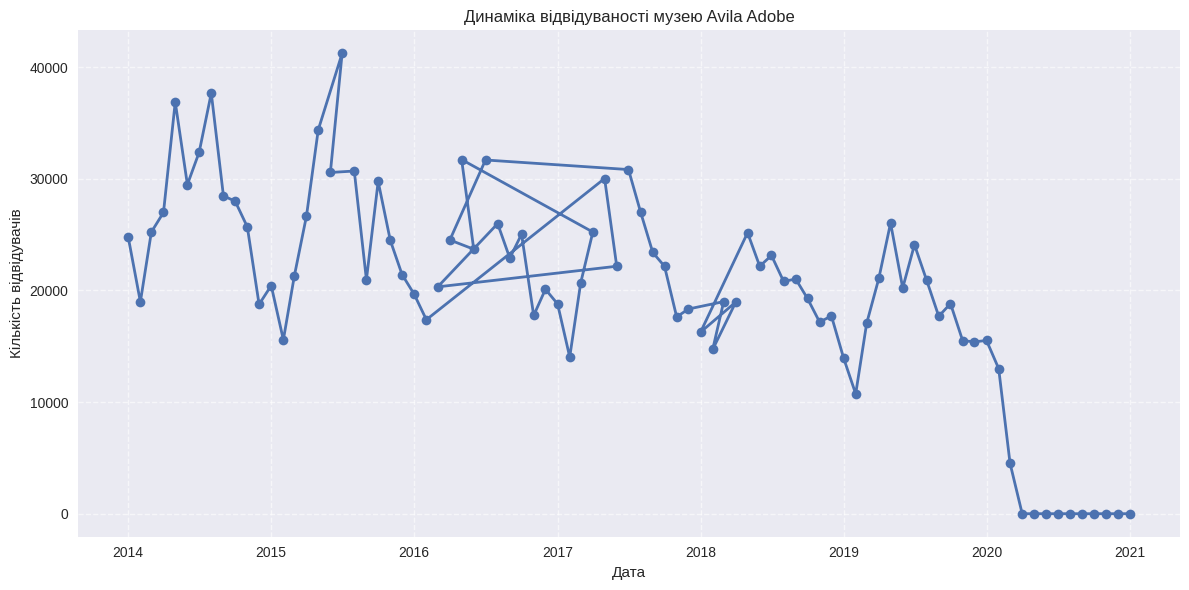

In [19]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

plt.figure(figsize=(12, 6))

plt.plot(df["date"], df["avila_adobe"], marker='o', linewidth=2)

plt.xlabel("Дата")
plt.ylabel("Кількість відвідувачів")
plt.title("Динаміка відвідуваності музею Avila Adobe")

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

Boxplot (розподіл відвідувачів Chinese American Museum по роках)

Heatmap (кореляція між музеями)

/tmp/ipykernel_2391/1277097900.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=years)


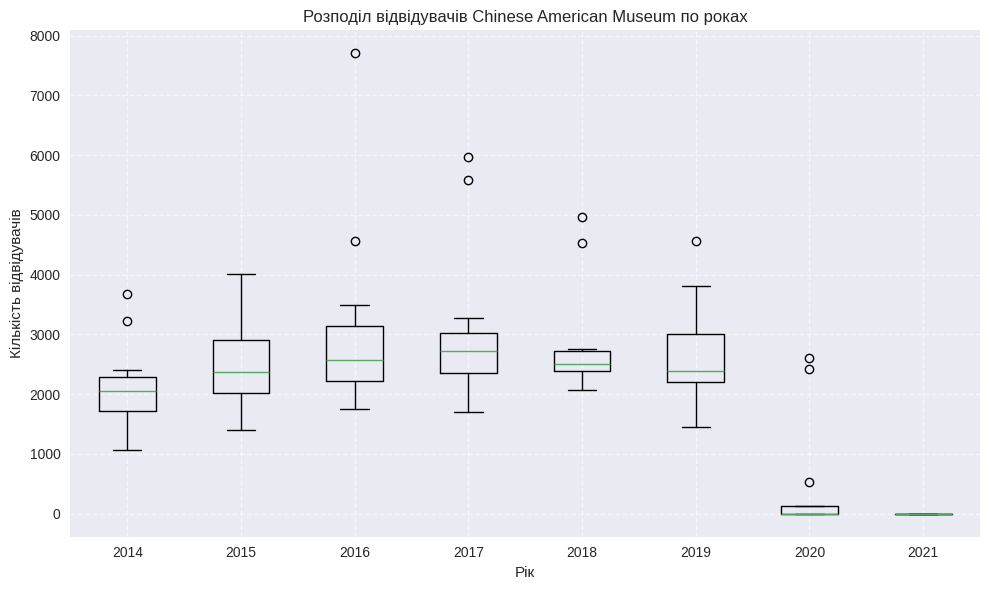

In [22]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
df["year"] = df["date"].dt.year
years = sorted(df["year"].unique())
data = [df[df["year"] == y]["chinese_american_museum"] for y in years]

plt.figure(figsize=(10, 6))
plt.boxplot(data, labels=years)
plt.xlabel("Рік")
plt.ylabel("Кількість відвідувачів")
plt.title("Розподіл відвідувачів Chinese American Museum по роках")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Histogram (розподіл кількості відвідувачів Gateway to Nature Center)

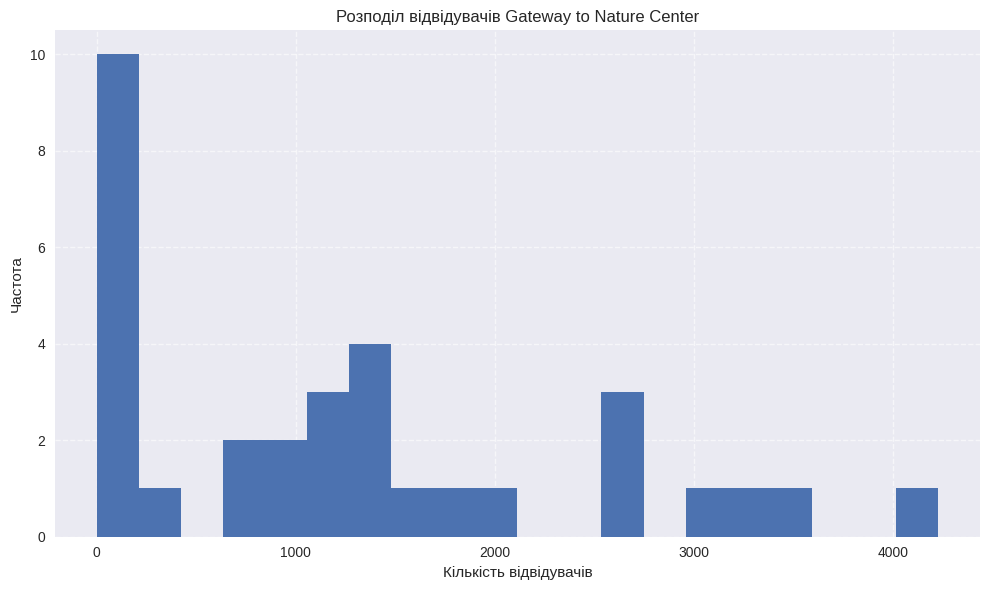

In [23]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

plt.figure(figsize=(10, 6))
plt.hist(df["gateway_to_nature_center"].dropna(), bins=20)
plt.xlabel("Кількість відвідувачів")
plt.ylabel("Частота")
plt.title("Розподіл відвідувачів Gateway to Nature Center")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Barplot (середня кількість відвідувачів по музеях за всі роки)



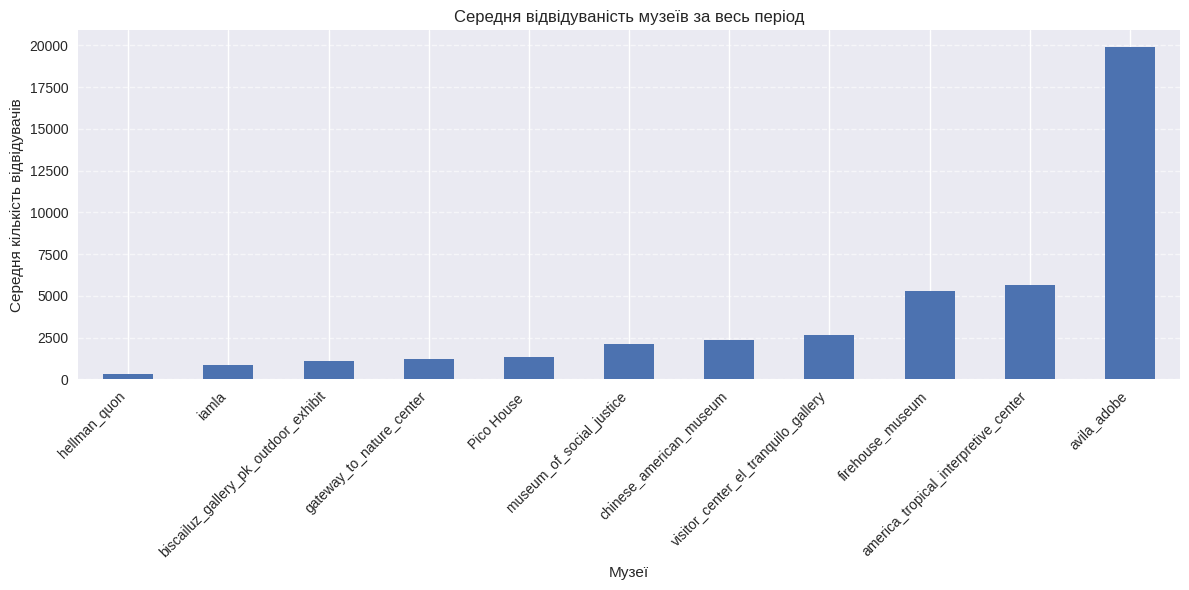

In [24]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
museum_cols = df.columns.drop(["date", "year"])

means = df[museum_cols].mean()

plt.figure(figsize=(12, 6))

means.sort_values().plot(kind="bar")

plt.xlabel("Музеї")
plt.ylabel("Середня кількість відвідувачів")
plt.title("Середня відвідуваність музеїв за весь період")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Висновки: У ході роботи було проаналізовано дані про відвідуваність музеїв за кілька років. Було виявлено пропуски в даних, але загалом датасет придатний для аналізу після базової обробки.
Аналіз показав, що відвідуваність музеїв має чітку сезонність — у літні місяці показники вищі, ніж у зимові. Найпопулярнішим серед розглянутих музеїв є Avila Adobe, тоді як інші мають значно нижчі середні значення.
Кореляційний аналіз підтвердив наявність зв’язків між відвідуваністю різних музеїв, що може пояснюватися спільними зовнішніми факторами (сезонність, туристичні потоки).
Візуалізації допомогли краще зрозуміти структуру даних, розподіли та загальні тенденції у відвідуваності.

Завдання 2. Завантажити датасет "Пігвіни", вивести дані.
Побудувати 5 графіків з використанням бібліотеки seaborn

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


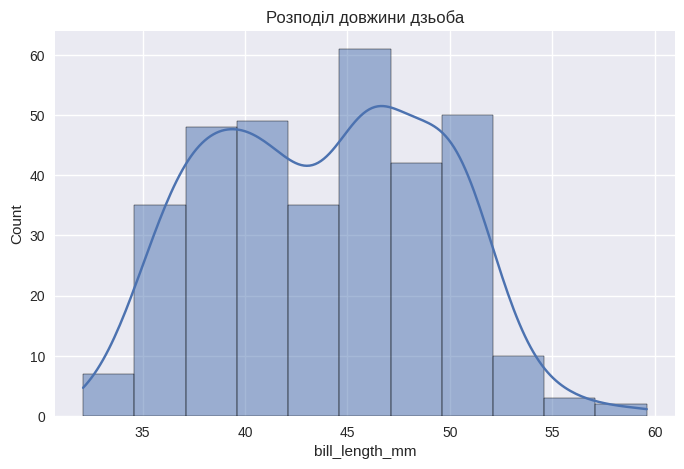

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df["bill_length_mm"].dropna(), kde=True)
plt.title("Розподіл довжини дзьоба")
plt.show()

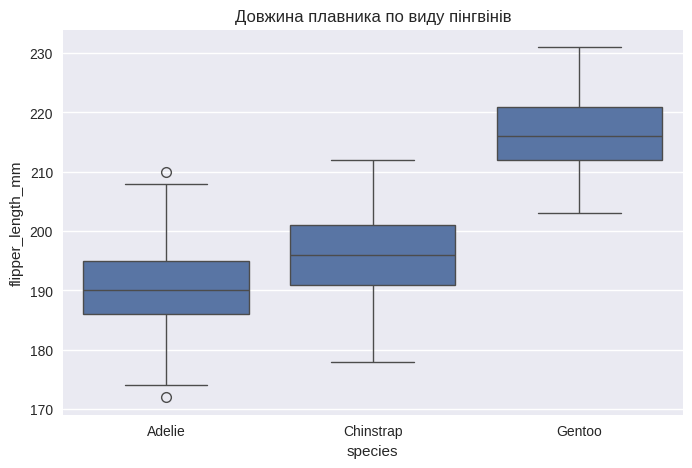

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(x="species", y="flipper_length_mm", data=df)
plt.title("Довжина плавника по виду пінгвінів")
plt.show()

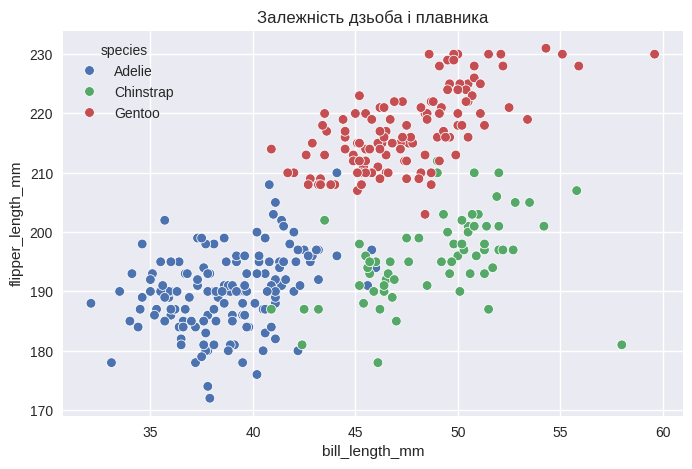

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="species",
    data=df
)
plt.title("Залежність дзьоба і плавника")
plt.show()

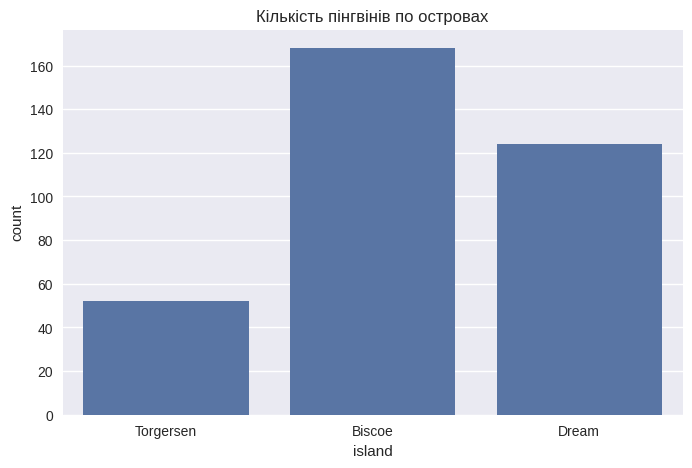

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(x="island", data=df)
plt.title("Кількість пінгвінів по островах")
plt.show()

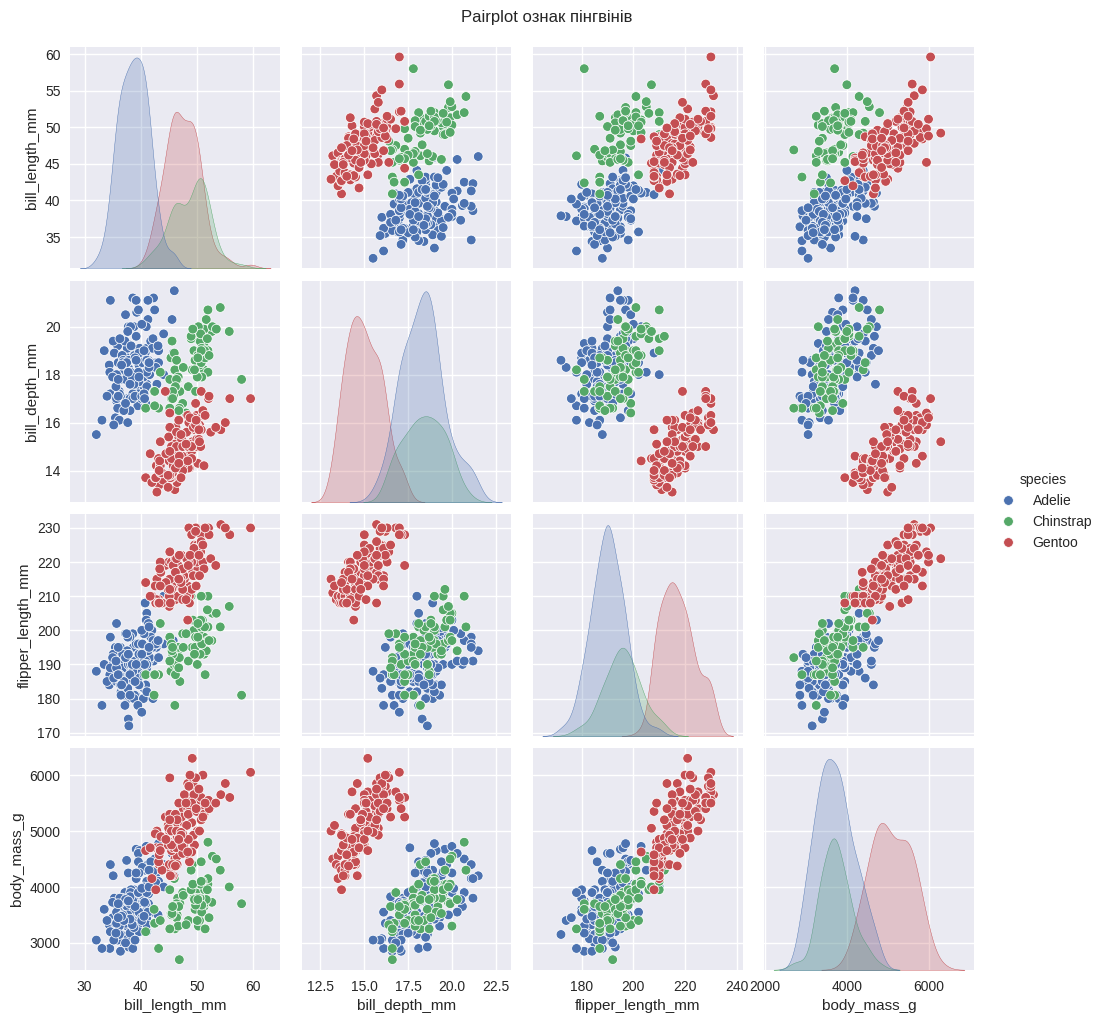

In [33]:
sns.pairplot(df.dropna(), hue="species")
plt.suptitle("Pairplot ознак пінгвінів", y=1.02)
plt.show()